## Parameter Inference

   Defaults: φ=0.8, σ=1.0, ν=8, w=1.0

### Score-Driven Case: Joint MLE of Parameters


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from dataclasses import replace

import robust_ssm as ss

SEED      = 123
N_REPS    = 200
N_ITER    = 4000
N_PARTICLES = 500
N_PART_PMCMC = 1000

TRUE = dict(phi=0.8, sigma=1.0, nu=8.0, w=1.0)
p_true = ss.ModelParams(phi=TRUE['phi'], sigma=TRUE['sigma'],
                        nu=TRUE['nu'], w=TRUE['w'], T=1000, N=N_PARTICLES, seed=SEED)

In [2]:
rng = np.random.default_rng(SEED)
mu_true, y = ss.simulate(p_true, rng)

### Score-Driven Profile Log-Likelihoods (φ, σ, ν)

At each grid point the named parameter is fixed and κ is re-optimised as a nuisance.
All other structural parameters are held at their true values.
The dashed vertical line marks the true value; the dotted horizontal line marks Wilks' threshold for an approximate 95% confidence interval.

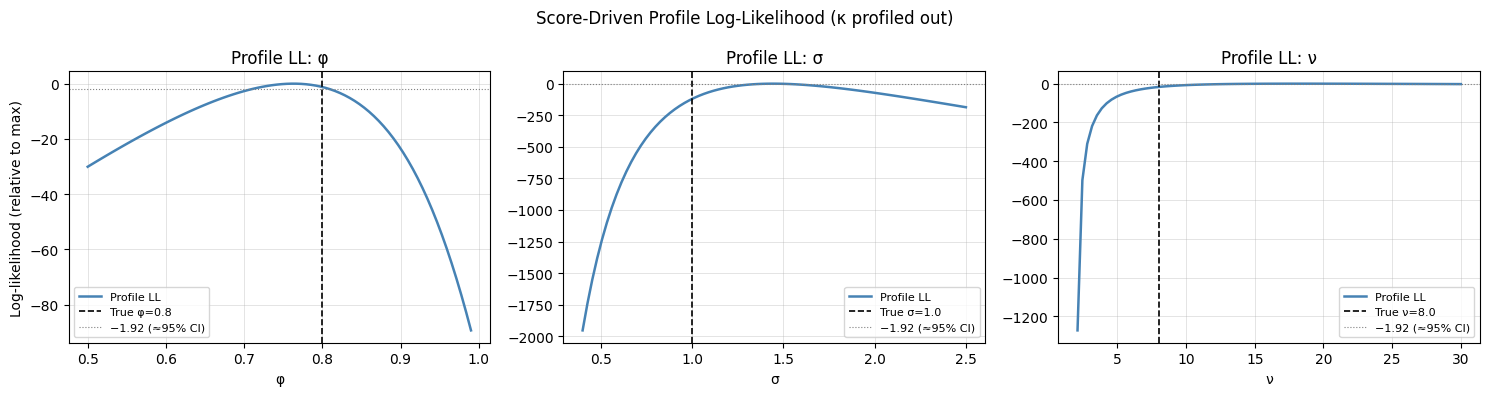

In [3]:
PROFILES = [
    ('phi',   'φ',  TRUE['phi'],   np.linspace(0.50,  0.99, 80)),
    ('sigma', 'σ',  TRUE['sigma'], np.linspace(0.40,  2.50, 80)),
    ('nu',    'ν',  TRUE['nu'],    np.linspace(2.10, 30.00, 80)),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Score-Driven Profile Log-Likelihood (κ profiled out)', fontsize=12)

for i, (ax, (param, label, true_val, grid)) in enumerate(zip(axes, PROFILES)):
    ll = np.empty(len(grid))
    for j, val in enumerate(grid):
        p_val = replace(p_true, **{param: val})
        res   = ss.estimate_sd_params_ml(y, p_val, free=('kappa',))
        ll[j] = -res['neg_loglik']
    ll -= ll.max()

    ax.plot(grid, ll, color='steelblue', lw=1.8, label='Profile LL')
    ax.axvline(true_val, c='k',    lw=1.2, ls='--', label=f'True {label}={true_val}')
    ax.axhline(-1.92,    c='gray', lw=0.8, ls=':',  label='−1.92 (≈95% CI)')
    ax.set_xlabel(label)
    if i == 0:
        ax.set_ylabel('Log-likelihood (relative to max)')
    ax.set_title(f'Profile LL: {label}')
    ax.legend(fontsize=8)
    ax.grid(True, lw=0.4, alpha=0.6)

plt.tight_layout()
plt.show()

## Score Driven Inference Replications

Run N_REPS independent datasets and collect the estimated posterior mean for φ and σ separately

In [4]:
phi_sd_mc   = []
sigma_sd_mc = []
nu_sd_mc    = []

print(f'Running: {N_REPS} reps...')
for i in range(N_REPS):
    p_i    = replace(p_true, seed=SEED + i)
    rng_i  = np.random.default_rng(SEED + i)
    _, y_i = ss.simulate(p_i, rng_i)

    phi_sd_mc.append(ss.estimate_sd_params_ml(y_i, p_i, free=('phi', 'kappa'))['phi'])
    sigma_sd_mc.append(ss.estimate_sd_params_ml(y_i, p_i, free=('kappa', 'sigma'))['sigma'])
    nu_sd_mc.append(ss.estimate_sd_params_ml(y_i, p_i, free=('nu', 'kappa'))['nu'])

    if (i + 1) % 20 == 0:
        print(f'  {i+1}/{N_REPS}')

phi_sd_mc   = np.array(phi_sd_mc)
sigma_sd_mc = np.array(sigma_sd_mc)
nu_sd_mc    = np.array(nu_sd_mc)

print(f'\nφ  SD MLE: mean={phi_sd_mc.mean():.4f}  std={phi_sd_mc.std():.4f}  (true={TRUE["phi"]})')
print(f'σ  SD MLE: mean={sigma_sd_mc.mean():.4f}  std={sigma_sd_mc.std():.4f}  (true={TRUE["sigma"]})')
print(f'ν  SD MLE: mean={nu_sd_mc.mean():.4f}  std={nu_sd_mc.std():.4f}  (true={TRUE["nu"]})')

Running: 200 reps...
  20/200
  40/200
  60/200
  80/200
  100/200
  120/200
  140/200
  160/200
  180/200
  200/200

φ  SD MLE: mean=0.7970  std=0.0350  (true=0.8)
σ  SD MLE: mean=1.4496  std=0.0335  (true=1.0)
ν  SD MLE: mean=14.9362  std=3.2303  (true=8.0)


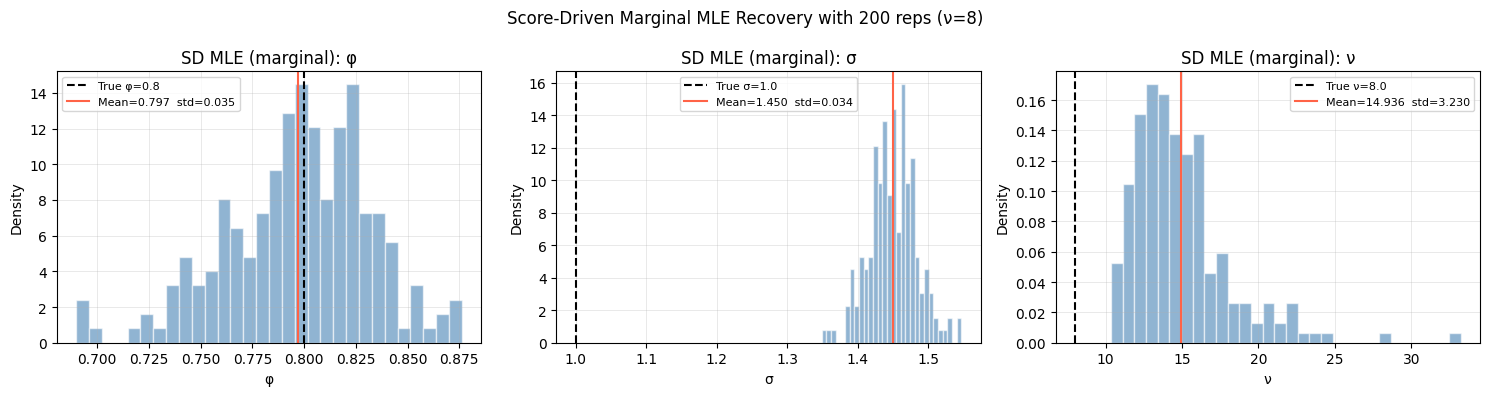

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Score-Driven Marginal MLE Recovery with {N_REPS} reps (ν=8)', fontsize=12)

for ax, vals, name, true_val in [
    (axes[0], phi_sd_mc,   'φ', TRUE['phi']),
    (axes[1], sigma_sd_mc, 'σ', TRUE['sigma']),
    (axes[2], nu_sd_mc,    'ν', TRUE['nu']),
]:
    ax.hist(vals, bins=30, density=True, color='steelblue', alpha=0.6, edgecolor='white')
    ax.axvline(true_val,    color='k',      ls='--', lw=1.5, label=f'True {name}={true_val}')
    ax.axvline(vals.mean(), color='tomato', ls='-',  lw=1.5,
               label=f'Mean={vals.mean():.3f}  std={vals.std():.3f}')
    ax.set_xlabel(name); ax.set_ylabel('Density')
    ax.set_title(f'SD MLE (marginal): {name}')
    ax.legend(fontsize=8)
    ax.grid(True, lw=0.4, alpha=0.5)

plt.tight_layout()
plt.show()

In [6]:
rows = []
for name, vals, true_val in [
    ('φ',  phi_sd_mc,   TRUE['phi']),
    ('σ',  sigma_sd_mc, TRUE['sigma']),
    ('ν',  nu_sd_mc,    TRUE['nu']),
]:
    bias = vals.mean() - true_val
    rows.append({
        'Parameter': name,
        'True':      true_val,
        'Mean':      round(vals.mean(), 4),
        'Std':       round(vals.std(),  4),
        'Bias':      round(bias,        4),
        'RMSE':      round(np.sqrt(np.mean((vals - true_val)**2)), 4),
    })

df = pd.DataFrame(rows).set_index('Parameter')
display(
    df.style
    .set_caption(f'Score-Driven Marginal MLE: {N_REPS} reps (each parameter estimated with others fixed at true values)')
    .set_properties(**{'text-align': 'center'})
)

,True,Mean,Std,Bias,RMSE
Parameter,,,,,
φ,0.800000,0.797000,0.035000,-0.003000,0.035200
σ,1.000000,1.449600,0.033500,0.449600,0.450900
ν,8.000000,14.936200,3.230300,6.936200,7.651600


# Joint estimation of parameters:

In [7]:
# single simulated dataset, ν=8
p_inf   = ss.ModelParams(nu=8.0, phi=0.8, sigma=1.0, w=1.0, T=1000, N=1000, seed=SEED)
rng_inf = np.random.default_rng(SEED)
mu_inf, y_inf = ss.simulate(p_inf, rng_inf)

res_all = ss.estimate_sd_params_ml(y_inf, p_inf, free=('phi', 'sigma', 'nu', 'kappa'))

print('Joint MLE results (all structural parameters free):')
print(f"  phi   : MLE={res_all['phi']:.4f}   true=0.8000")
print(f"  sigma : MLE={res_all['sigma']:.4f}  true=1.0000")
print(f"  nu    : MLE={res_all['nu']:.4f}   true=8.0000")
print(f"  kappa : MLE={res_all['kappa']:.4f}  (filter gain, no DGP counterpart)")
print(f"  Optimizer converged: {res_all['success']}")

Joint MLE results (all structural parameters free):
  phi   : MLE=0.7607   true=0.8000
  sigma : MLE=1.3789  true=1.0000
  nu    : MLE=35.1030   true=8.0000
  kappa : MLE=0.5851  (filter gain, no DGP counterpart)
  Optimizer converged: True


## Score-Driven Joint MLE: Replications

In [8]:
joint_phi_sd_mc   = []
joint_sigma_sd_mc = []
joint_nu_sd_mc    = []

print(f'Running joint SD MLE: {N_REPS} reps...')
for i in range(N_REPS):
    p_i    = replace(p_true, seed=SEED + i)
    rng_i  = np.random.default_rng(SEED + i)
    _, y_i = ss.simulate(p_i, rng_i)

    res = ss.estimate_sd_params_ml(y_i, p_i, free=('phi', 'sigma', 'nu', 'kappa'))
    joint_phi_sd_mc.append(res['phi'])
    joint_sigma_sd_mc.append(res['sigma'])
    joint_nu_sd_mc.append(res['nu'])

    if (i + 1) % 20 == 0:
        print(f'  {i+1}/{N_REPS}')

joint_phi_sd_mc   = np.array(joint_phi_sd_mc)
joint_sigma_sd_mc = np.array(joint_sigma_sd_mc)
joint_nu_sd_mc    = np.array(joint_nu_sd_mc)

print(f'\nφ  joint SD MLE: mean={joint_phi_sd_mc.mean():.4f}  std={joint_phi_sd_mc.std():.4f}  (true={TRUE["phi"]})')
print(f'σ  joint SD MLE: mean={joint_sigma_sd_mc.mean():.4f}  std={joint_sigma_sd_mc.std():.4f}  (true={TRUE["sigma"]})')
print(f'ν  joint SD MLE: mean={joint_nu_sd_mc.mean():.4f}  std={joint_nu_sd_mc.std():.4f}  (true={TRUE["nu"]})')

Running joint SD MLE: 200 reps...
  20/200
  40/200
  60/200
  80/200
  100/200
  120/200
  140/200
  160/200
  180/200
  200/200

φ  joint SD MLE: mean=0.7971  std=0.0345  (true=0.8)
σ  joint SD MLE: mean=1.3986  std=0.0326  (true=1.0)
ν  joint SD MLE: mean=33.2125  std=28.0840  (true=8.0)


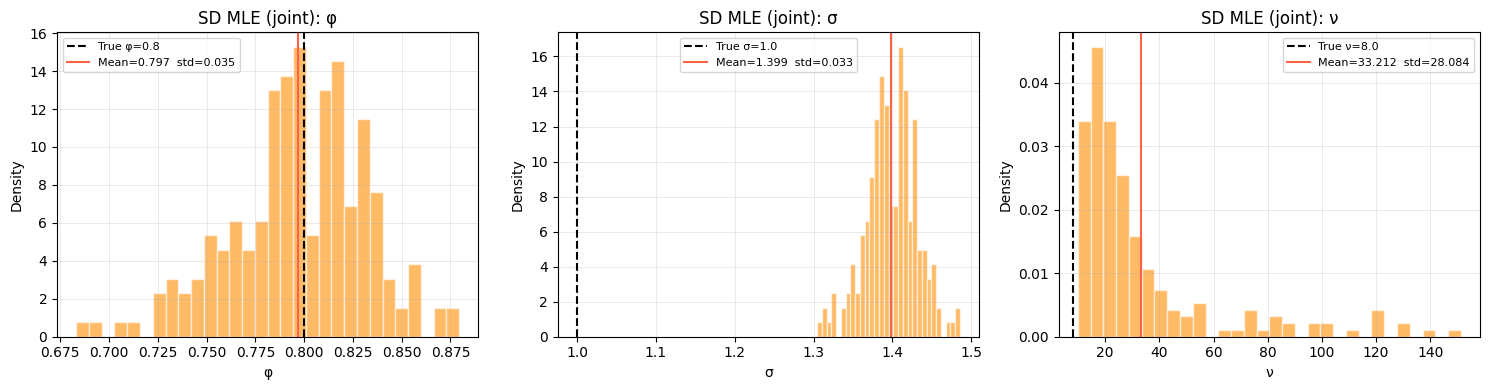

,True,Mean,Std,Bias,RMSE
Parameter,,,,,
φ,0.800000,0.797100,0.034500,-0.002900,0.034600
σ,1.000000,1.398600,0.032600,0.398600,0.400000
ν,8.000000,33.212500,28.084000,25.212500,37.740900


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, vals, name, true_val in [
    (axes[0], joint_phi_sd_mc,   'φ', TRUE['phi']),
    (axes[1], joint_sigma_sd_mc, 'σ', TRUE['sigma']),
    (axes[2], joint_nu_sd_mc,    'ν', TRUE['nu']),
]:
    ax.hist(vals, bins=30, density=True, color='darkorange', alpha=0.6, edgecolor='white')
    ax.axvline(true_val,    color='k',      ls='--', lw=1.5, label=f'True {name}={true_val}')
    ax.axvline(vals.mean(), color='tomato', ls='-',  lw=1.5,
               label=f'Mean={vals.mean():.3f}  std={vals.std():.3f}')
    ax.set_xlabel(name); ax.set_ylabel('Density')
    ax.set_title(f'SD MLE (joint): {name}')
    ax.legend(fontsize=8)
    ax.grid(True, lw=0.4, alpha=0.5)

plt.tight_layout()
plt.show()

rows = []
for name, vals, true_val in [
    ('φ', joint_phi_sd_mc,   TRUE['phi']),
    ('σ', joint_sigma_sd_mc, TRUE['sigma']),
    ('ν', joint_nu_sd_mc,    TRUE['nu']),
]:
    bias = vals.mean() - true_val
    rows.append({
        'Parameter': name,
        'True':      true_val,
        'Mean':      round(vals.mean(), 4),
        'Std':       round(vals.std(),  4),
        'Bias':      round(bias,        4),
        'RMSE':      round(np.sqrt(np.mean((vals - true_val)**2)), 4),
    })

df_joint_sd = pd.DataFrame(rows).set_index('Parameter')
display(
    df_joint_sd.style
    .set_caption(f'Score-Driven Joint MLE (φ, σ, ν free): {N_REPS} reps, T=1000')
    .set_properties(**{'text-align': 'center'})
)

## PMCMC

In [10]:
# identifying sds for the gaussian random walk which gives a reasonable acceptance ratio
def tune_proposal_sd(y, p, param, n_iter=300, n_particles=None,
                     target=(0.20, 0.35), seed=0):
    """Binary search for proposal_sd which hit the target acceptance band."""
    lo, hi = 1e-4, 2.0
    sd = 0.05
    for round_ in range(12):
        res = ss.pmcmc_inference(
            y, p, n_iter=n_iter, free=(param,),
            proposal_sd={param: sd}, n_particles=n_particles,
            seed=seed, reparameterise=False,
            resample_threshold=1.0,   # simplification, resample at every step
        )

        rate = res['accept_rate']
        print(f"  {param}  sd={sd:.5f}  acceptance={rate:.3f}")
        if rate < target[0]:
            hi = sd
        elif rate > target[1]:
            lo = sd
        else:
            print(f"  -> Done: proposal_sd['{param}'] = {sd:.5f}")
            return sd
        sd = (lo + hi) / 2
    print(f"  -> Best found: proposal_sd['{param}'] = {sd:.5f}")
    return sd

rng_tune = np.random.default_rng(SEED)
_, y_tune = ss.simulate(p_true, rng_tune)

print("Tuning phi...")
phi_sd   = tune_proposal_sd(y_tune, p_true, 'phi',   n_particles=N_PART_PMCMC)
print("\nTuning sigma...")
sigma_sd = tune_proposal_sd(y_tune, p_true, 'sigma', n_particles=N_PART_PMCMC)
print("\nTuning nu...")
nu_sd    = tune_proposal_sd(y_tune, p_true, 'nu',    n_particles=N_PART_PMCMC)

print(f"\nFinal: proposal_sd = {{'phi': {phi_sd:.5f}, 'sigma': {sigma_sd:.5f}, 'nu': {nu_sd:.5f}}}")


Tuning phi...
  [PMCMC] phi    acceptance rate: 0.323  (ok)
  phi  sd=0.05000  acceptance=0.323
  -> Done: proposal_sd['phi'] = 0.05000

Tuning sigma...
  [PMCMC] sigma  acceptance rate: 0.333  (ok)
  sigma  sd=0.05000  acceptance=0.333
  -> Done: proposal_sd['sigma'] = 0.05000

Tuning nu...
  [PMCMC] nu     acceptance rate: 0.390  (ok)
  nu  sd=0.05000  acceptance=0.390
  [PMCMC] nu     acceptance rate: 0.363  (ok)
  nu  sd=1.02500  acceptance=0.363
  [PMCMC] nu     acceptance rate: 0.367  (ok)
  nu  sd=1.51250  acceptance=0.367
  [PMCMC] nu     acceptance rate: 0.367  (ok)
  nu  sd=1.75625  acceptance=0.367
  [PMCMC] nu     acceptance rate: 0.430  (ok)
  nu  sd=1.87813  acceptance=0.430
  [PMCMC] nu     acceptance rate: 0.360  (ok)
  nu  sd=1.93906  acceptance=0.360
  [PMCMC] nu     acceptance rate: 0.323  (ok)
  nu  sd=1.96953  acceptance=0.323
  -> Done: proposal_sd['nu'] = 1.96953

Final: proposal_sd = {'phi': 0.05000, 'sigma': 0.05000, 'nu': 1.96953}


In [ ]:
# PMCMC MC parameter recovery study
# For each of N_MC_PMCMC independent datasets we run four PMCMC chains:
#   1. φ  free, σ/ν/w fixed at true values  (marginal)
#   2. σ  free, φ/ν/w fixed at true values  (marginal)
#   3. ν  free, φ/σ/w fixed at true values  (marginal)
#   4. (φ, σ, ν) free, w fixed at true      (joint blocked MWG)
#
# Each PMCMC step is a full particle filter run: O(N_PART_PMCMC × T) operations.
# The joint chain (4) runs 3 filter calls per iteration (one MH step per parameter).
N_MC_PMCMC   = 5     # MC replications  (will be 20 on HPC)
N_ITER_PMCMC = 500   # MCMC iterations per rep  (will be 2000 on HPC)
BURN_PMCMC   = N_ITER_PMCMC // 2

phi_pmcmc_mc   = []
sigma_pmcmc_mc = []
nu_pmcmc_mc    = []
joint_phi_mc   = []
joint_sigma_mc = []
joint_nu_mc    = []

print(f"PMCMC MC study: {N_MC_PMCMC} datasets × 4 chains "
      f"(N={N_PART_PMCMC} particles, {N_ITER_PMCMC} iterations each)")
print(f"Chains 1-3: marginal | Chain 4: joint (φ, σ, ν)\n")

for i in range(N_MC_PMCMC):
    rng_i  = np.random.default_rng(SEED + i)
    p_i    = replace(p_true, seed=SEED + i, N=N_PART_PMCMC)
    _, y_i = ss.simulate(p_i, rng_i)

    # chain 1: φ free (σ, ν, w fixed at true values)
    res_phi = ss.pmcmc_inference(
        y_i, p_i,
        resample_threshold=1,
        n_iter=N_ITER_PMCMC,
        free=('phi',),
        proposal_sd={'phi': phi_sd},
        n_particles=N_PART_PMCMC,
        seed=SEED + i,
        reparameterise=False,
    )
    phi_pmcmc_mc.append(res_phi['samples']['phi'][BURN_PMCMC:].mean())

    # chain 2: σ free (φ, ν, w fixed at true values)
    res_sigma = ss.pmcmc_inference(
        y_i, p_i,
        resample_threshold=1,
        n_iter=N_ITER_PMCMC,
        free=('sigma',),
        proposal_sd={'sigma': sigma_sd},
        n_particles=N_PART_PMCMC,
        seed=SEED + i,
        reparameterise=False,
    )
    sigma_pmcmc_mc.append(res_sigma['samples']['sigma'][BURN_PMCMC:].mean())

    # chain 3: ν free (φ, σ, w fixed at true values)
    res_nu = ss.pmcmc_inference(
        y_i, p_i,
        resample_threshold=1,
        n_iter=N_ITER_PMCMC,
        free=('nu',),
        proposal_sd={'nu': nu_sd},
        n_particles=N_PART_PMCMC,
        seed=SEED + i,
        reparameterise=False,
    )
    nu_pmcmc_mc.append(res_nu['samples']['nu'][BURN_PMCMC:].mean())

    # chain 4: joint (φ, σ, ν) — blocked MWG, one MH step per param per iteration.
    # same marginal step sizes, each iteration runs 3 filter calls.
    res_joint = ss.pmcmc_inference(
        y_i, p_i,
        resample_threshold=1,
        n_iter=N_ITER_PMCMC,
        free=('phi', 'sigma', 'nu'),
        proposal_sd={'phi': phi_sd, 'sigma': sigma_sd, 'nu': nu_sd},
        n_particles=N_PART_PMCMC,
        seed=SEED + i,
        reparameterise=False,
    )
    joint_phi_mc.append(res_joint['samples']['phi'][BURN_PMCMC:].mean())
    joint_sigma_mc.append(res_joint['samples']['sigma'][BURN_PMCMC:].mean())
    joint_nu_mc.append(res_joint['samples']['nu'][BURN_PMCMC:].mean())

    if (i + 1) % 5 == 0:
        print(f"  {i+1}/{N_MC_PMCMC}  "
              f"φ̄={phi_pmcmc_mc[-1]:.3f}  σ̄={sigma_pmcmc_mc[-1]:.3f}  ν̄={nu_pmcmc_mc[-1]:.2f}  |  "
              f"joint φ̄={joint_phi_mc[-1]:.3f}  σ̄={joint_sigma_mc[-1]:.3f}  ν̄={joint_nu_mc[-1]:.2f}")

phi_pmcmc_mc   = np.array(phi_pmcmc_mc)
sigma_pmcmc_mc = np.array(sigma_pmcmc_mc)
nu_pmcmc_mc    = np.array(nu_pmcmc_mc)
joint_phi_mc   = np.array(joint_phi_mc)
joint_sigma_mc = np.array(joint_sigma_mc)
joint_nu_mc    = np.array(joint_nu_mc)

print(f"\nMarginal chains:")
print(f"  φ: mean={phi_pmcmc_mc.mean():.4f}  std={phi_pmcmc_mc.std():.4f}  (true={TRUE['phi']})")
print(f"  σ: mean={sigma_pmcmc_mc.mean():.4f}  std={sigma_pmcmc_mc.std():.4f}  (true={TRUE['sigma']})")
print(f"  ν: mean={nu_pmcmc_mc.mean():.4f}  std={nu_pmcmc_mc.std():.4f}  (true={TRUE['nu']})")
print(f"\nJoint chain (φ, σ, ν):")
print(f"  φ: mean={joint_phi_mc.mean():.4f}  std={joint_phi_mc.std():.4f}  (true={TRUE['phi']})")
print(f"  σ: mean={joint_sigma_mc.mean():.4f}  std={joint_sigma_mc.std():.4f}  (true={TRUE['sigma']})")
print(f"  ν: mean={joint_nu_mc.mean():.4f}  std={joint_nu_mc.std():.4f}  (true={TRUE['nu']})")


PMCMC MC study: 5 datasets × 4 chains (N=1000 particles, 500 iterations each)
Chains 1-3: marginal | Chain 4: joint (φ, σ, ν)

  [PMCMC] phi    acceptance rate: 0.260  (ok)
  [PMCMC] sigma  acceptance rate: 0.268  (ok)
  [PMCMC] nu     acceptance rate: 0.360  (ok)
  [PMCMC] phi    acceptance rate: 0.230  (ok)
  [PMCMC] sigma  acceptance rate: 0.346  (ok)
  [PMCMC] nu     acceptance rate: 0.362  (ok)
  [PMCMC] phi    acceptance rate: 0.210  (ok)
  [PMCMC] sigma  acceptance rate: 0.350  (ok)
  [PMCMC] nu     acceptance rate: 0.400  (ok)
  [PMCMC] phi    acceptance rate: 0.226  (ok)
  [PMCMC] sigma  acceptance rate: 0.306  (ok)
  [PMCMC] nu     acceptance rate: 0.378  (ok)
  [PMCMC] phi    acceptance rate: 0.210  (ok)
  [PMCMC] sigma  acceptance rate: 0.344  (ok)
  [PMCMC] nu     acceptance rate: 0.402  (ok)
  [PMCMC] phi    acceptance rate: 0.242  (ok)
  [PMCMC] sigma  acceptance rate: 0.314  (ok)
  [PMCMC] nu     acceptance rate: 0.382  (ok)
  [PMCMC] phi    acceptance rate: 0.246  (ok)

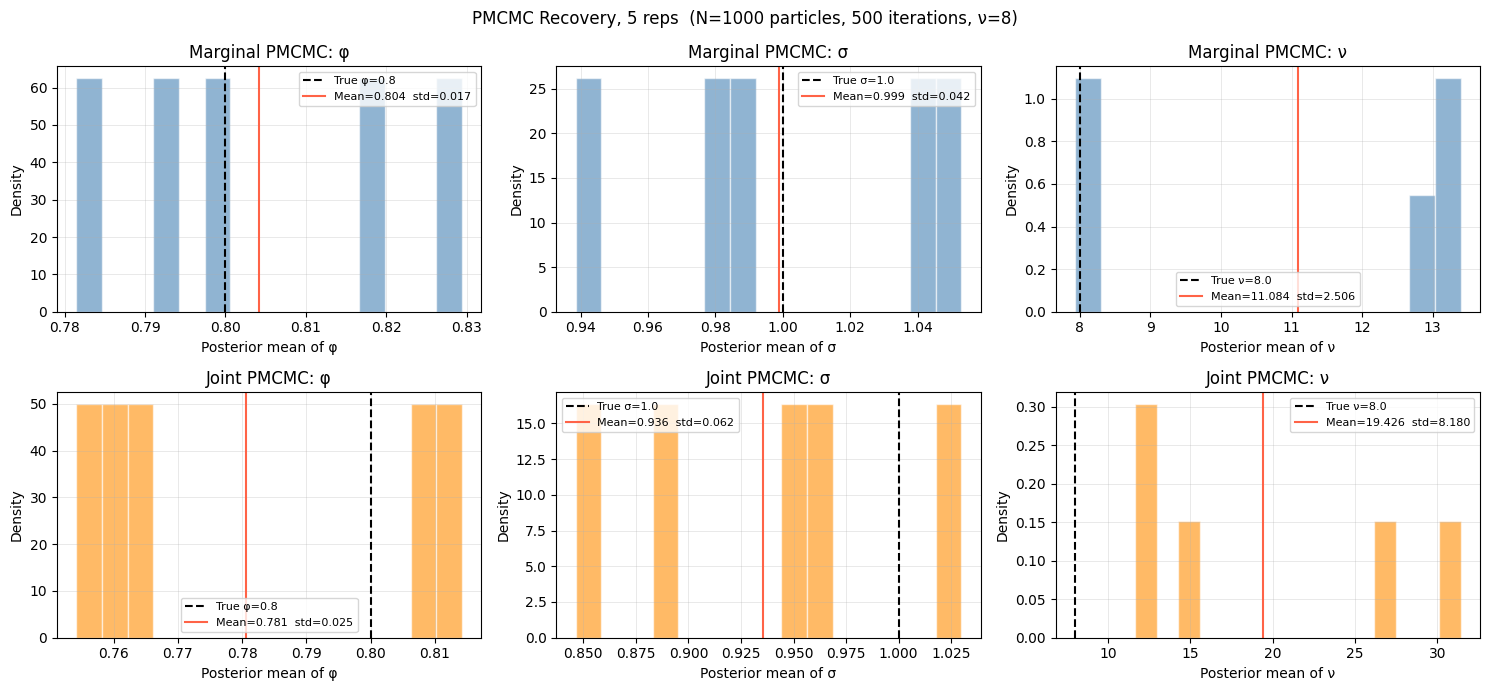

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle(
    f'PMCMC Recovery, {N_MC_PMCMC} reps  '
    f'(N={N_PART_PMCMC} particles, {N_ITER_PMCMC} iterations, ν=8)',
    fontsize=12,
)

# marginal posteriors
for col, (vals, name, true_val) in enumerate([
    (phi_pmcmc_mc,   'φ', TRUE['phi']),
    (sigma_pmcmc_mc, 'σ', TRUE['sigma']),
    (nu_pmcmc_mc,    'ν', TRUE['nu']),
]):
    ax = axes[0, col]
    ax.hist(vals, bins=15, density=True, color='steelblue', alpha=0.6, edgecolor='white')
    ax.axvline(true_val,    color='k',      ls='--', lw=1.5, label=f'True {name}={true_val}')
    ax.axvline(vals.mean(), color='tomato', ls='-',  lw=1.5,
               label=f'Mean={vals.mean():.3f}  std={vals.std():.3f}')
    ax.set_xlabel(f'Posterior mean of {name}')
    ax.set_ylabel('Density')
    ax.set_title(f'Marginal PMCMC: {name}')
    ax.legend(fontsize=8)
    ax.grid(True, lw=0.4, alpha=0.5)

# joint chain posteriors
for col, (vals, name, true_val) in enumerate([
    (joint_phi_mc,   'φ', TRUE['phi']),
    (joint_sigma_mc, 'σ', TRUE['sigma']),
    (joint_nu_mc,    'ν', TRUE['nu']),
]):
    ax = axes[1, col]
    ax.hist(vals, bins=15, density=True, color='darkorange', alpha=0.6, edgecolor='white')
    ax.axvline(true_val,    color='k',      ls='--', lw=1.5, label=f'True {name}={true_val}')
    ax.axvline(vals.mean(), color='tomato', ls='-',  lw=1.5,
               label=f'Mean={vals.mean():.3f}  std={vals.std():.3f}')
    ax.set_xlabel(f'Posterior mean of {name}')
    ax.set_ylabel('Density')
    ax.set_title(f'Joint PMCMC: {name}')
    ax.legend(fontsize=8)
    ax.grid(True, lw=0.4, alpha=0.5)

plt.tight_layout()
plt.show()

not really useful at this scale, needs to be run with more reps in HPC.

In [13]:
rows = []
for name, vals, true_val in [
    ('φ  (marginal)',   phi_pmcmc_mc,   TRUE['phi']),
    ('σ  (marginal)',   sigma_pmcmc_mc, TRUE['sigma']),
    ('ν  (marginal)',   nu_pmcmc_mc,    TRUE['nu']),
    ('φ  (joint)',      joint_phi_mc,   TRUE['phi']),
    ('σ  (joint)',      joint_sigma_mc, TRUE['sigma']),
    ('ν  (joint)',      joint_nu_mc,    TRUE['nu']),
]:
    bias = vals.mean() - true_val
    rows.append({
        'Parameter': name,
        'True':      true_val,
        'Mean est.': round(vals.mean(), 4),
        'Std':       round(vals.std(),  4),
        'Bias':      round(bias,        4),
        'RMSE':      round(np.sqrt(np.mean((vals - true_val)**2)), 4),
    })

df_pmcmc = pd.DataFrame(rows).set_index('Parameter')
display(
    df_pmcmc.style
    .set_caption(f'PMCMC Parameter Inference: {N_MC_PMCMC} reps, T=1000, '
                 f'N={N_PART_PMCMC} particles, {N_ITER_PMCMC} iterations')
    .set_properties(**{'text-align': 'center'})
)


,True,Mean est.,Std,Bias,RMSE
Parameter,,,,,
φ (marginal),0.800000,0.804100,0.017300,0.004100,0.017800
σ (marginal),1.000000,0.999000,0.042000,-0.001000,0.042000
ν (marginal),8.000000,11.084300,2.506100,3.084300,3.974100
φ (joint),0.800000,0.780600,0.024800,-0.019400,0.031500
σ (joint),1.000000,0.935600,0.062100,-0.064400,0.089500
ν (joint),8.000000,19.425600,8.180100,11.425600,14.052000


### σ recovery vs ν

In [ ]:
NU_SWEEP_VALS = [3, 5, 8, 15, 300]
N_MC_SWEEP    = 3    # 5 on HPC
N_ITER_SWEEP  = 200  # 500 on HPC
N_PART_SWEEP  = N_PART_PMCMC
BURN_SWEEP    = N_ITER_SWEEP // 2

nu_sweep_sd    = {}
nu_sweep_pmcmc = {}

print(f"σ recovery sweep over ν: {NU_SWEEP_VALS}")
print(f"  {N_MC_SWEEP} reps | {N_ITER_SWEEP} PMCMC iters | {N_PART_SWEEP} particles\n")

for nu_val in NU_SWEEP_VALS:
    p_nu = ss.ModelParams(phi=TRUE['phi'], sigma=TRUE['sigma'],
                          nu=float(nu_val), w=TRUE['w'], T=300, N=N_PART_SWEEP, seed=SEED)
    sd_ests, pmcmc_ests = [], []

    for i in range(N_MC_SWEEP):
        rng_i  = np.random.default_rng(SEED + i)
        p_i    = replace(p_nu, seed=SEED + i)
        _, y_i = ss.simulate(p_i, rng_i)

        # SD MLE
        sd_ests.append(ss.estimate_sd_params_ml(y_i, p_i, free=('kappa', 'sigma'))['sigma'])

        # PMCMC
        res = ss.pmcmc_inference(
            y_i, p_i,
            resample_threshold=1.0, # the default value
            n_iter=N_ITER_SWEEP,
            free=('sigma',),
            proposal_sd={'sigma': sigma_sd},
            n_particles=N_PART_SWEEP,
            seed=SEED + i,
            reparameterise=False,
        )
        pmcmc_ests.append(res['samples']['sigma'][BURN_SWEEP:].mean())

    nu_sweep_sd[nu_val]    = np.array(sd_ests)
    nu_sweep_pmcmc[nu_val] = np.array(pmcmc_ests)
    print(f"  ν={nu_val:>4}  "
          f"SD: mean={nu_sweep_sd[nu_val].mean():.3f}  "
          f"rmse={np.sqrt(np.mean((nu_sweep_sd[nu_val] - TRUE['sigma'])**2)):.3f}  |  "
          f"PMCMC: mean={nu_sweep_pmcmc[nu_val].mean():.3f}  "
          f"rmse={np.sqrt(np.mean((nu_sweep_pmcmc[nu_val] - TRUE['sigma'])**2)):.3f}")

σ recovery sweep over ν: [3, 5, 8, 15, 300]
  3 reps | 200 PMCMC iters | 1000 particles

  [PMCMC] sigma  acceptance rate: 0.585  (TUNE proposal_sd)
  [PMCMC] sigma  acceptance rate: 0.645  (TUNE proposal_sd)
  [PMCMC] sigma  acceptance rate: 0.650  (TUNE proposal_sd)
  ν=   3  SD: mean=1.647  rmse=0.650  |  PMCMC: mean=1.098  rmse=0.124
  [PMCMC] sigma  acceptance rate: 0.615  (TUNE proposal_sd)
  [PMCMC] sigma  acceptance rate: 0.535  (TUNE proposal_sd)
  [PMCMC] sigma  acceptance rate: 0.610  (TUNE proposal_sd)
  ν=   5  SD: mean=1.442  rmse=0.453  |  PMCMC: mean=1.007  rmse=0.115
  [PMCMC] sigma  acceptance rate: 0.565  (TUNE proposal_sd)
  [PMCMC] sigma  acceptance rate: 0.560  (TUNE proposal_sd)
  [PMCMC] sigma  acceptance rate: 0.585  (TUNE proposal_sd)
  ν=   8  SD: mean=1.425  rmse=0.431  |  PMCMC: mean=0.956  rmse=0.091
  [PMCMC] sigma  acceptance rate: 0.620  (TUNE proposal_sd)
  [PMCMC] sigma  acceptance rate: 0.595  (TUNE proposal_sd)
  [PMCMC] sigma  acceptance rate: 0.60

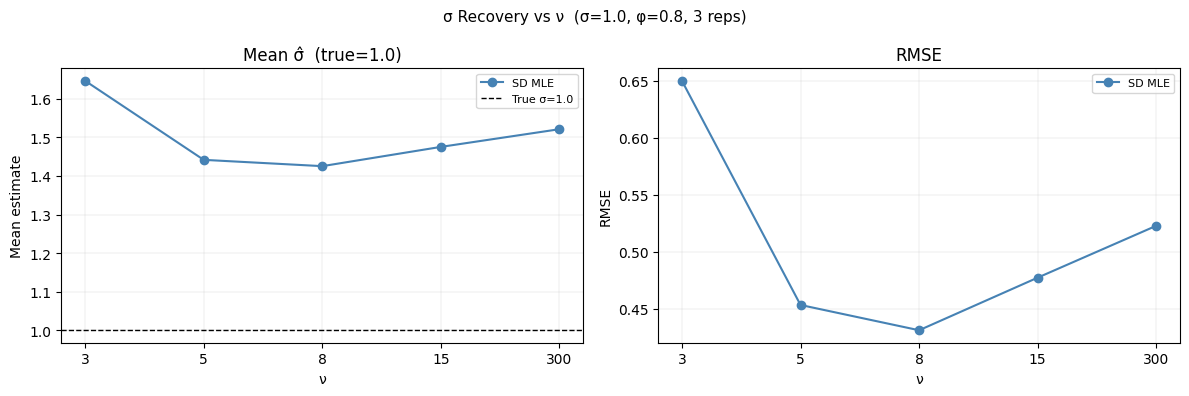

,Mean,Std,Bias,RMSE
ν,,,,
3,1.646800,0.066000,0.646800,0.650100
5,1.441800,0.100900,0.441800,0.453200
8,1.425500,0.068700,0.425500,0.431000
15,1.475400,0.041200,0.475400,0.477200
300,1.521300,0.039200,0.521300,0.522800


In [16]:
TRUE_SIGMA = TRUE['sigma']
nus = list(NU_SWEEP_VALS)

sd_means = [nu_sweep_sd[v].mean()                               for v in nus]
sd_rmse  = [np.sqrt(np.mean((nu_sweep_sd[v] - TRUE_SIGMA)**2)) for v in nus]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'σ Recovery vs ν  (σ=1.0, φ=0.8, {N_MC_SWEEP} reps)', fontsize=11)

x_pos    = range(len(nus))
x_labels = [str(v) for v in nus]

for ax, title, sd_y, ylabel in [
    (axes[0], 'Mean σ̂  (true=1.0)', sd_means, 'Mean estimate'),
    (axes[1], 'RMSE',                sd_rmse,  'RMSE'),
]:
    ax.plot(x_pos, sd_y, 'o-', color='steelblue', label='SD MLE')
    if title.startswith('Mean'):
        ax.axhline(TRUE_SIGMA, color='k', ls='--', lw=1, label=f'True σ={TRUE_SIGMA}')
    ax.set_xticks(x_pos); ax.set_xticklabels(x_labels)
    ax.set_xlabel('ν'); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(fontsize=8); ax.grid(True, lw=0.3, alpha=0.5)

plt.tight_layout()
plt.savefig('figs/sd_sigma_vs_nu.png', dpi=150, bbox_inches='tight')
plt.show()

# summary table (SD MLE only)
rows = []
for v in nus:
    ests = nu_sweep_sd[v]
    bias = ests.mean() - TRUE_SIGMA
    rows.append({'ν': v, 'Mean': round(ests.mean(), 4),
                 'Std': round(ests.std(), 4), 'Bias': round(bias, 4),
                 'RMSE': round(np.sqrt(np.mean((ests - TRUE_SIGMA)**2)), 4)})
df_nu = pd.DataFrame(rows).set_index('ν')
display(df_nu.style.set_caption(f'SD MLE σ Recovery vs ν, {N_MC_SWEEP} reps, T=300, σ_true=1.0'))

### σ Recovery vs True σ

In [17]:
SIGMA_SWEEP_VALS = [0.5, 1.0, 2.0, 3.0]

sigma_sweep_sd    = {}
sigma_sweep_pmcmc = {}

print(f"σ recovery sweep over σ: {SIGMA_SWEEP_VALS}")
print(f"  {N_MC_SWEEP} reps | {N_ITER_SWEEP} PMCMC iters | {N_PART_SWEEP} particles\n")

for sigma_val in SIGMA_SWEEP_VALS:
    p_sv = ss.ModelParams(phi=TRUE['phi'], sigma=sigma_val,
                          nu=TRUE['nu'], w=TRUE['w'], T=300, N=N_PART_SWEEP, seed=SEED)
    # Scale proposal_sd proportionally so the relative step size is ~constant.
    prop_sd = 0.03 * sigma_val
    sd_ests, pmcmc_ests = [], []

    for i in range(N_MC_SWEEP):
        rng_i  = np.random.default_rng(SEED + i)
        p_i    = replace(p_sv, seed=SEED + i)
        _, y_i = ss.simulate(p_i, rng_i)

        # SD MLE
        sd_ests.append(ss.estimate_sd_params_ml(y_i, p_i, free=('kappa', 'sigma'))['sigma'])

        # PMCMC
        res = ss.pmcmc_inference(
            y_i, p_i,
            resample_threshold=0.5,
            n_iter=N_ITER_SWEEP,
            free=('sigma',),
            proposal_sd={'sigma': prop_sd},
            n_particles=N_PART_SWEEP,
            seed=SEED + i,
            reparameterise=False,
        )
        pmcmc_ests.append(res['samples']['sigma'][BURN_SWEEP:].mean())

    sigma_sweep_sd[sigma_val]    = np.array(sd_ests)
    sigma_sweep_pmcmc[sigma_val] = np.array(pmcmc_ests)
    print(f"  σ={sigma_val:.1f}  "
          f"SD: mean={sigma_sweep_sd[sigma_val].mean():.3f}  "
          f"rmse={np.sqrt(np.mean((sigma_sweep_sd[sigma_val] - sigma_val)**2)):.3f}  |  "
          f"PMCMC: mean={sigma_sweep_pmcmc[sigma_val].mean():.3f}  "
          f"rmse={np.sqrt(np.mean((sigma_sweep_pmcmc[sigma_val] - sigma_val)**2)):.3f}")

σ recovery sweep over σ: [0.5, 1.0, 2.0, 3.0]
  3 reps | 200 PMCMC iters | 1000 particles

  [PMCMC] sigma  acceptance rate: 0.145  (TUNE proposal_sd)
  [PMCMC] sigma  acceptance rate: 0.315  (ok)
  [PMCMC] sigma  acceptance rate: 0.425  (ok)
  σ=0.5  SD: mean=1.052  rmse=0.556  |  PMCMC: mean=0.441  rmse=0.066
  [PMCMC] sigma  acceptance rate: 0.185  (ok)
  [PMCMC] sigma  acceptance rate: 0.335  (ok)
  [PMCMC] sigma  acceptance rate: 0.345  (ok)
  σ=1.0  SD: mean=1.425  rmse=0.431  |  PMCMC: mean=0.784  rmse=0.225
  [PMCMC] sigma  acceptance rate: 0.490  (TUNE proposal_sd)
  [PMCMC] sigma  acceptance rate: 0.450  (TUNE proposal_sd)
  [PMCMC] sigma  acceptance rate: 0.400  (ok)
  σ=2.0  SD: mean=2.295  rmse=0.306  |  PMCMC: mean=1.778  rmse=0.236
  [PMCMC] sigma  acceptance rate: 0.730  (TUNE proposal_sd)
  [PMCMC] sigma  acceptance rate: 0.290  (ok)
  [PMCMC] sigma  acceptance rate: 0.635  (TUNE proposal_sd)
  σ=3.0  SD: mean=3.217  rmse=0.244  |  PMCMC: mean=2.934  rmse=0.230


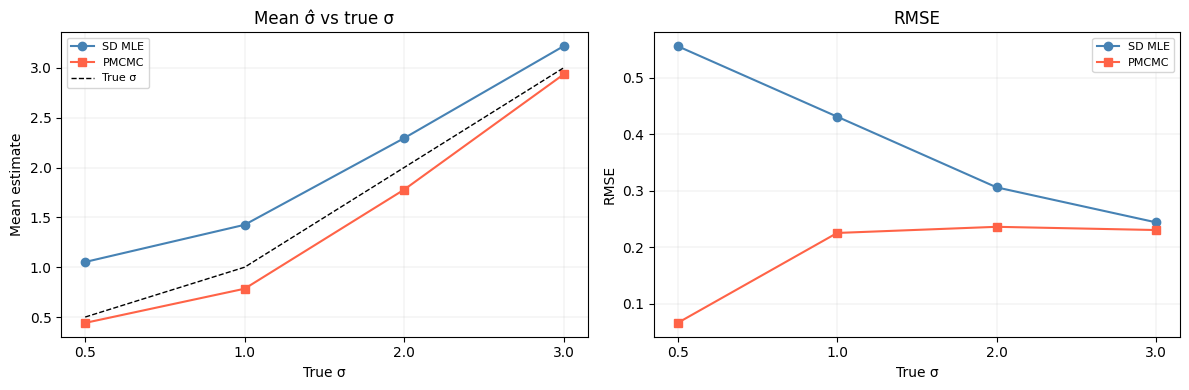

In [18]:
sigmas = list(SIGMA_SWEEP_VALS)

sd_means_sv    = [sigma_sweep_sd[v].mean()    for v in sigmas]
sd_rmse_sv     = [np.sqrt(np.mean((sigma_sweep_sd[v]    - v)**2)) for v in sigmas]
pmcmc_means_sv = [sigma_sweep_pmcmc[v].mean() for v in sigmas]
pmcmc_rmse_sv  = [np.sqrt(np.mean((sigma_sweep_pmcmc[v] - v)**2)) for v in sigmas]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x_pos_sv    = range(len(sigmas))
x_labels_sv = [str(v) for v in sigmas]

for ax, title, sd_y, pmcmc_y, ylabel, add_diag in [
    (axes[0], 'Mean σ̂ vs true σ', sd_means_sv, pmcmc_means_sv, 'Mean estimate', True),
    (axes[1], 'RMSE',              sd_rmse_sv,  pmcmc_rmse_sv,  'RMSE',          False),
]:
    ax.plot(x_pos_sv, sd_y,    'o-', color='steelblue', label='SD MLE')
    ax.plot(x_pos_sv, pmcmc_y, 's-', color='tomato',    label='PMCMC')
    if add_diag:
        ax.plot(x_pos_sv, sigmas, 'k--', lw=1, label='True σ')
    ax.set_xticks(x_pos_sv); ax.set_xticklabels(x_labels_sv)
    ax.set_xlabel('True σ'); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(fontsize=8); ax.grid(True, lw=0.3, alpha=0.5)

plt.tight_layout()
plt.show()

# summary table
rows = []
for v in sigmas:
    for label, ests in [('SD MLE', sigma_sweep_sd[v]), ('PMCMC', sigma_sweep_pmcmc[v])]:
        bias = ests.mean() - v
        rows.append({'True σ': v, 'Method': label, 'Mean': round(ests.mean(), 4),
                     'Std': round(ests.std(), 4), 'Bias': round(bias, 4),
                     'RMSE': round(np.sqrt(np.mean((ests - v)**2)), 4)})
df_sv = pd.DataFrame(rows).set_index(['True σ', 'Method'])
display(df_sv.style.set_caption(f'σ Recovery vs True σ. {N_MC_SWEEP} reps, T=300, ν=8'))

### Reparameterisation Comparison

Does proposing in unconstrained space actually improve mixing over
proposing directly in the original constrained space?

In [ ]:
from scipy.signal import correlate

def chain_ess(x):
    """Effective sample size via autocorrelation truncation (Geyer 1992);
    formula from BDA3 §11.5."""
    n   = len(x)
    x   = x - x.mean()
    acf = correlate(x, x, mode='full')[n - 1:]
    acf = acf / acf[0]
    cutoff = next((k for k in range(1, len(acf)) if acf[k] < 0), len(acf))
    return n / max(1 + 2 * acf[1:cutoff].sum(), 1.0)

FREE_COMP   = ('phi', 'sigma')
BURNIN_COMP = N_ITER_PMCMC // 2

p_comp = replace(p_true, N=N_PART_PMCMC)

print("--- With reparameterisation (logit/log) ---")
res_reparam = ss.pmcmc_inference(
    y_tune, p_comp,
    n_iter=N_ITER_PMCMC,
    free=FREE_COMP,
    proposal_sd={'phi': phi_sd, 'sigma': sigma_sd},
    n_particles=N_PART_PMCMC,
    seed=SEED,
    reparameterise=True,
)

print("\n--- Without reparameterisation (constrained space) ---")
res_noreparam = ss.pmcmc_inference(
    y_tune, p_comp,
    n_iter=N_ITER_PMCMC,
    free=FREE_COMP,
    proposal_sd={'phi': phi_sd, 'sigma': sigma_sd},
    n_particles=N_PART_PMCMC,
    seed=SEED,
    reparameterise=False,
)

# ESS comparison (post-burnin)
print(f"\n{'Parameter':>10}  {'ESS (reparam)':>15}  {'ESS (no reparam)':>16}  {'Ratio':>8}")
for name in FREE_COMP:
    s_r  = res_reparam['samples'][name][BURNIN_COMP:]
    s_nr = res_noreparam['samples'][name][BURNIN_COMP:]
    ess_r, ess_nr = chain_ess(s_r), chain_ess(s_nr)
    print(f"  {name:8s}  {ess_r:>15.1f}  {ess_nr:>16.1f}  {ess_r/max(ess_nr,1):>8.2f}x")

--- With reparameterisation (logit/log) ---
  [PMCMC] phi    acceptance rate: 0.470  (TUNE proposal_sd)
  [PMCMC] sigma  acceptance rate: 0.384  (ok)

--- Without reparameterisation (constrained space) ---
  [PMCMC] phi    acceptance rate: 0.254  (ok)
  [PMCMC] sigma  acceptance rate: 0.374  (ok)

 Parameter    ESS (reparam)  ESS (no reparam)     Ratio
  phi                  15.1              22.2      0.68x
  sigma                38.0              39.3      0.97x


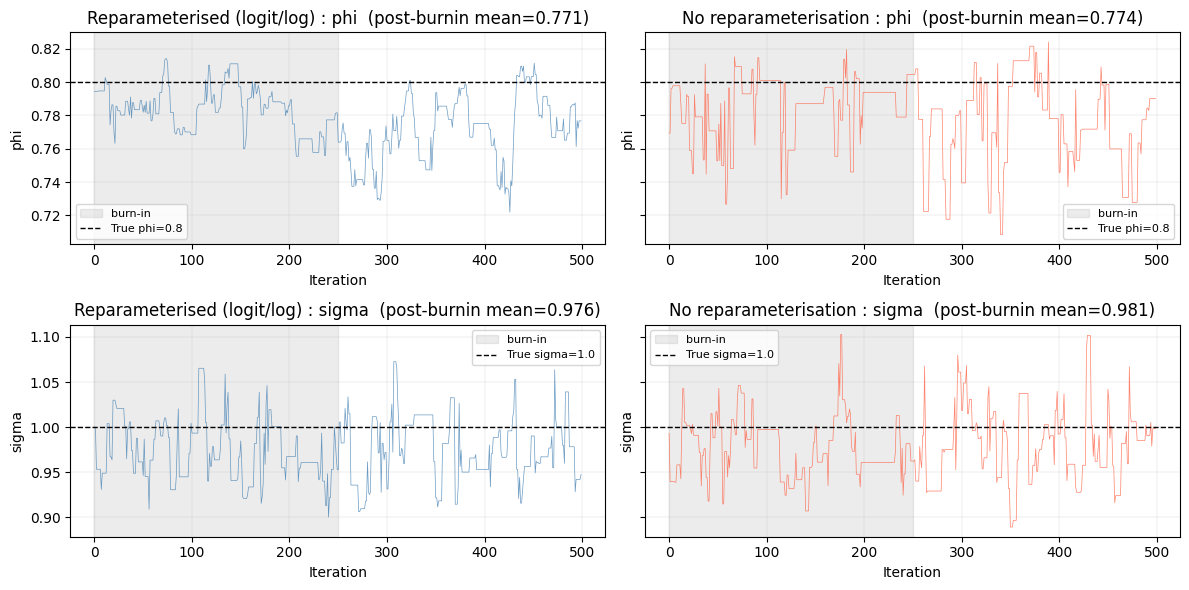

In [20]:
# traces
fig, axes = plt.subplots(len(FREE_COMP), 2, figsize=(12, 3 * len(FREE_COMP)), sharey='row')

for row, name in enumerate(FREE_COMP):
    true_val = TRUE[name]
    for col, (res, label, colour) in enumerate([
        (res_reparam,   'Reparameterised (logit/log)', 'steelblue'),
        (res_noreparam, 'No reparameterisation',       'tomato'),
    ]):
        ax = axes[row, col]
        ax.plot(res['samples'][name], lw=0.5, color=colour, alpha=0.8)
        ax.axvspan(0, BURNIN_COMP, color='grey', alpha=0.15, label='burn-in')
        ax.axhline(true_val, color='k', ls='--', lw=1.0, label=f'True {name}={true_val}')
        s_post = res['samples'][name][BURNIN_COMP:]
        ax.set_title(f'{label} : {name}  (post-burnin mean={s_post.mean():.3f})')
        ax.set_xlabel('Iteration')
        ax.set_ylabel(name)
        ax.legend(fontsize=8)
        ax.grid(True, lw=0.3, alpha=0.5)

plt.tight_layout()
plt.show()